In [2]:
import numpy as np
pmt_dtype = np.dtype(
    [
        ("ChannelID", "<i4"),
        ("x", "<f8"),
        ("y", "<f8"),
        ("z", "<f8"),
        ("rot_x", "<f8"),
        ("rot_y", "<f8"),
        ("rot_z", "<f8"),
    ]
)
pmt_top = np.loadtxt("./LCE_info/topPMTs.txt", dtype=pmt_dtype)
pmt_bot = np.loadtxt("./LCE_info/botPMTs.txt", dtype=pmt_dtype)

In [3]:
def generate_cube_surface(size, num_points_per_edge, center, angle):  
    # 生成每个面的坐标点  
    u = np.linspace(-size/2, size/2, num_points_per_edge)  
    v = np.linspace(-size/2, size/2, num_points_per_edge)  
    U, V = np.meshgrid(u, v)
    # print(U_, V_)
    # U = np.cos(angle) * U_ - np.sin(angle) * V_
    # V = np.sin(angle) * U_ + np.cos(angle) * V_
    # print(U,V)

    # 定义每个面的顶点坐标，并考虑中心位置  
    cx, cy, cz = center  
    faces = []  

    # 前面和后面  
    for z in [-size/2, size/2]:  
        Z = z * np.ones_like(U)  # 平移Z坐标  
        # faces.append((U + cx, V + cy, Z))  
        faces.append((np.cos(angle) * U - np.sin(angle) * V + cx,
                      np.sin(angle) * U + np.cos(angle) * V + cy,
                      Z + cz ))  

    # 左面和右面  
    for x in [-size/2, size/2]:  
        X = x * np.ones_like(U)   # 平移X坐标  
        # faces.append((X, U + cy, V + cz))
        faces.append((np.cos(angle) * X - np.sin(angle) * U + cx, 
                      np.sin(angle) * X + np.cos(angle) * U + cy, 
                      V + cz))  

    # 底面和顶面  
    for y in [-size/2, size/2]:  
        Y = y * np.ones_like(U)  # 平移Y坐标  
        # faces.append((U + cx,Y + cy,V + cz))  
        faces.append((np.cos(angle) * U - np.sin(angle) * Y + cx,
                      np.sin(angle) * U + np.cos(angle) * Y + cy,
                      V + cz))  

    return faces 

0
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209


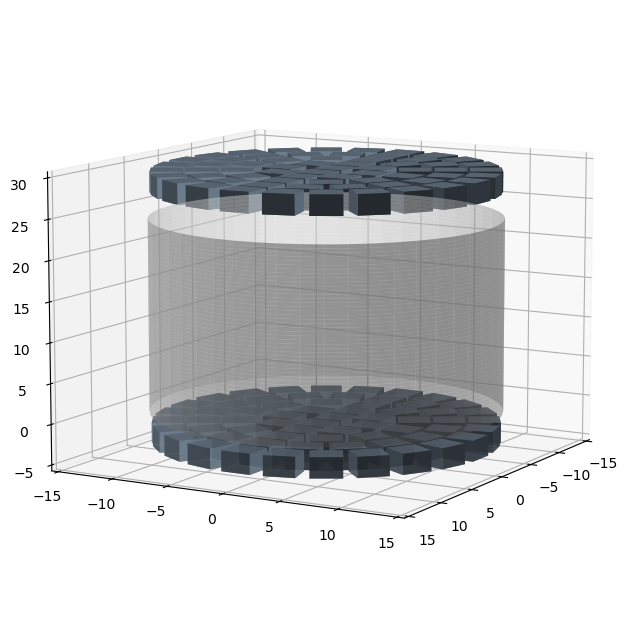

In [9]:
import numpy as np  
import matplotlib.pyplot as plt  
from mpl_toolkits.mplot3d import Axes3D  
from matplotlib.animation import FuncAnimation  
from matplotlib.patches import Rectangle

# 设置圆柱体参数  
radius = 14  
height = 24
num_points_cylinder = 50  # 圆柱体侧面的点数（不影响动画中的点）  
num_electrons = 4   # 动画中移动的点数  
theta = np.linspace(0, 2 * np.pi, num_points_cylinder)  
z_values = np.linspace(0, height, num_points_cylinder)  


# 设置动图总帧数
# pre_frames = 3
# signal_frames = 20
# post_frames = 3
pre_frames = 30
s1_frames = 30
s2_frames = 120
post_frames = 30

# 初始化移动点的位置和速度  
# initial_z_positions = np.concatenate([np.ones(int(num_moving_points )) * 5])  # 初始都在z=0 
# initial_x_positions = np.concatenate([np.ones(int(num_moving_points )) * -3])
# initial_y_positions = np.concatenate([np.ones(int(num_moving_points )) * -2])
# muon_x_positions = muon_array[muon_array['eventId'] == eventID]['xd'] / 10
# muon_y_positions = muon_array[muon_array['eventId'] == eventID]['yd'] / 10
# muon_z_positions = (muon_array[muon_array['eventId'] == eventID]['zd'] +210) / 10
initial_x_positions = np.repeat(3, num_electrons)
initial_y_positions = np.repeat(4, num_electrons)
initial_z_positions = np.repeat(5, num_electrons)


speeds = np.random.normal(1, 0.1, len(initial_x_positions))  # 速度符合高斯分布  


# 绘制顶部PMT阵列
pmt_size = 2.54
num_points_per_edge = 2
top_pmt_faces_list = []
bot_pmt_faces_list = []
for pmt in pmt_top:
    top_pmt_faces = generate_cube_surface(pmt_size, num_points_per_edge,[pmt['x'],pmt['y'],height + pmt_size + 2],pmt['rot_z'] / 180 * np.pi) 
    top_pmt_faces_list.append(top_pmt_faces)
for pmt in pmt_top:
    bot_pmt_faces = generate_cube_surface(pmt_size, num_points_per_edge,[pmt['x'],pmt['y'],0 - pmt_size],pmt['rot_z'] / 180 * np.pi) 
    bot_pmt_faces_list.append(bot_pmt_faces)

# 初始化圆柱体表面  
def generate_cylinder(radius, height, num_points):  
    theta = np.linspace(0, 2 * np.pi, num_points)  
    z_values = np.linspace(0, height, num_points)  
    theta, z = np.meshgrid(theta, z_values)  
    x = radius * np.cos(theta)  
    y = radius * np.sin(theta)  
    return x, y, z
   
    
# 创建新的图形和3D坐标轴  
fig = plt.figure(figsize=(8,8))  
ax = fig.add_subplot(111, projection='3d')  
ax.view_init(elev=10, azim=30)

# 定义动态更新函数  
def update(frame): 
    ax.clear()
    print(frame)
    # 准备帧数和结束帧数
    if (frame < pre_frames) :
         # 生成圆柱体表面  
        x, y, z = generate_cylinder(radius, height, num_points_cylinder)
        ax.plot_surface(x, y, z, color='lightgrey', alpha=0.5)  

        for top_pmt_faces in top_pmt_faces_list:  
            for U, V, W in top_pmt_faces:
                ax.plot_surface(U, V, W, color='slategrey', alpha=1)  # alpha用于控制透明度 
        for bot_pmt_faces in bot_pmt_faces_list:
            for U, V, W in bot_pmt_faces:       
                ax.plot_surface(U, V, W, color='slategrey', alpha=0.8)  # alpha用于控制透明度  
                
    # 事件帧，
    if (frame >= pre_frames) and (frame < (pre_frames + s1_frames / 3)):
        # 生成圆柱体表面  
        x, y, z = generate_cylinder(radius, height, num_points_cylinder)
        ax.plot_surface(x, y, z, color='lightgrey', alpha=0.5)
        # 生成PMT阵列
        for top_pmt_faces in top_pmt_faces_list:  
            for U, V, W in top_pmt_faces:
                ax.plot_surface(U, V, W, color='slategrey', alpha=1)  # alpha用于控制透明度 
        for bot_pmt_faces in bot_pmt_faces_list:
            for U, V, W in bot_pmt_faces:       
                ax.plot_surface(U, V, W, color='slategrey', alpha=0.8)  # alpha用于控制透明度  
        # 生成事件碰撞点
        ax.scatter(initial_x_positions, 
                   initial_y_positions, 
                   initial_z_positions, 
                   color='darkorange', s=400, marker = '*')
        
    # S1
    if (frame >= pre_frames + s1_frames / 3) and (frame < (pre_frames + s1_frames)):
        # 生成圆柱体表面  
        x, y, z = generate_cylinder(radius, height, num_points_cylinder)
        # 光照渐变效果
        alpha = np.min([(frame - (pre_frames + s1_frames / 3)), 
                        ((pre_frames + s1_frames) - frame)]) / (s1_frames / 3) * 0.4
        ax.plot_surface(x, y, z, color='lightgrey', alpha=0.5)
        ax.plot_surface(x, y, z, color='darkorange', alpha= alpha) 
        # 生成PMT阵列
        for top_pmt_faces in top_pmt_faces_list:  
            for U, V, W in top_pmt_faces:
                ax.plot_surface(U, V, W, color='slategrey', alpha=1)  # alpha用于控制透明度 
        for bot_pmt_faces in bot_pmt_faces_list:
            for U, V, W in bot_pmt_faces:       
                ax.plot_surface(U, V, W, color='slategrey', alpha=0.8)  # alpha用于控制透明度  
        # 生成事件碰撞点
        ax.scatter(initial_x_positions, 
                   initial_y_positions, 
                   initial_z_positions, 
                   color='deepskyblue', s=20)  # 漂移区电子 
    # 漂移帧数
    if (frame >= pre_frames + s1_frames) and (frame < (pre_frames + s1_frames + s2_frames + post_frames)):
        # 更新移动点的位置  
        current_z_positions = initial_z_positions + speeds * ((frame - pre_frames - s1_frames) / s2_frames) * height  # 根据速度和帧号计算当前z位置  
        # 确保点不会超出圆柱体顶部  
        # current_z_positions = np.clip(current_z_positions, 0, height)  
        # 漂移区
        liquid_mask = current_z_positions < (height - 2 * height / s2_frames)
        S2_mask = (current_z_positions > (height - 2 * height / s2_frames)) * (current_z_positions < height)
        vanish_mask = current_z_positions > height

        # 生成圆柱体表面 ，对于muon不再画出S2光照效果
        x, y, z = generate_cylinder(radius, height, num_points_cylinder)
        ax.plot_surface(x, y, z, color='lightgrey', alpha=0.5)  

        for top_pmt_faces in top_pmt_faces_list:  
            for U, V, W in top_pmt_faces:
                ax.plot_surface(U, V, W, color='slategrey', alpha=1)  # alpha用于控制透明度 
        for bot_pmt_faces in bot_pmt_faces_list:
            for U, V, W in bot_pmt_faces:       
                ax.plot_surface(U, V, W, color='slategrey', alpha=0.8)  # alpha用于控制透明度  
        # 绘制移动点  
        ax.scatter(initial_x_positions[liquid_mask], 
                   initial_y_positions[liquid_mask], 
                   current_z_positions[liquid_mask], 
                   color='deepskyblue', s=20)  # 漂移区电子  
        ax.scatter(initial_x_positions[S2_mask], 
                   initial_y_positions[S2_mask], 
                   current_z_positions[S2_mask], 
                   color='darkorange', s=200, marker = '*')  # 拉出区电子
        
        # ax.plot(muon_x_positions, 
        #            muon_y_positions, 
        #            muon_z_positions, 
        #            'r--')
    
    # 设置坐标轴范围  
    ax.set_xlim(-15, 15)  
    ax.set_ylim(-15, 15)  
    ax.set_zlim(-5, 30)  
      
    return ax  
  
# 创建动画  
ani = FuncAnimation(fig, update, frames=pre_frames + s1_frames + s2_frames + post_frames, interval=33.3 , blit=False)  
  
# 保存动画为视频（需要ffmpeg）  
# ani.save('cylinder_with_moving_points.mp4', writer='ffmpeg', fps=20)  # 取消注释以保存为视频  
  
# 保存动画为动图  
ani.save('figure/tpc_s2_only.gif', writer='imagemagick', fps=30)  
  
# 显示图形（可选，如果你只想保存而不显示）  
plt.show()